In [2]:
from pathlib import Path
import pandas as pd
from neural_priors.utils.data import Subject, get_all_subject_ids
from tqdm.contrib.itertools import product

In [ ]:
modelz = {
    0:  'No shift (μ_wide = μ_narrow)',
    1:  'Fixed shift (δ=2, no range constraint)',
    2:  'Fitted shift ratio, shared across voxels',
    3:  'Fitted shift ratio, free per voxel',
    4:  'Efficient coding: fixed shift (δ=2)',
    5:  'Efficient coding: shared shift ratio',
    14: 'Free width ratio, per voxel',
    15: 'Fitted width scaling, shared across voxels',
    31: 'Fixed width scaling (δ_σ=1.29)',
    32: 'Fixed width scaling + free amplitude ratio',
    33: 'Fixed width scaling + shared amplitude ratio',
    34: 'Fixed tuning, free amplitude per voxel',
    35: 'Fixed tuning, shared amplitude ratio',
}

In [ ]:
bids_folder = Path('/data/ds-neuralpriors')

pars = pd.read_csv(
    bids_folder / 'derivatives' / 'summary_tsvs' / 'main_models_roi-NPCr_desc-groundtruth_parameters.tsv',
    sep='\t')

cvr2 = pars[['subject', 'model_label', 'model', 'response_fit', 'voxel', 'cvr2']]
cvr2 = cvr2[cvr2['cvr2'] > 0]

In [17]:
pars

parameter                                                                     mu  \
range                                                                     narrow   
subject response_fit     model                                                     
01      ground_truth 0   No shift                                      10.698851   
                     1   No shift                                      12.097051   
                     2   No shift                                      13.019329   
                     3   No shift                                      15.027272   
                     4   No shift                                      11.410503   
...                                                                          ...   
41      responses    689 Only amplitude free (subject-specific slope)  13.954379   
                     690 Only amplitude free (subject-specific slope)   6.049250   
                     691 Only amplitude free (subject-specific slope)  13.249113   
                     692 Only amplitude free (subject-specific slope)   6.319039   
                     693 Only amplitude free (subject-specific slope)   4.694068   

parameter                                                                         \
range                                                                       wide   
subject response_fit     model                                                     
01      ground_truth 0   No shift                                      10.698851   
                     1   No shift                                      12.097051   
                     2   No shift                                      13.019329   
                     3   No shift                                      15.027272   
                     4   No shift                                      11.410503   
...                                                                          ...   
41      responses    689 Only amplitude free (subject-specific slope)  13.954379   
                     690 Only amplitude free (subject-specific slope)   6.049250   
                     691 Only amplitude free (subject-specific slope)  13.249113   
                     692 Only amplitude free (subject-specific slope)   6.319039   
                     693 Only amplitude free (subject-specific slope)   4.694068   

parameter                                                                    sd  \
range                                                                    narrow   
subject response_fit     model                                                    
01      ground_truth 0   No shift                                      0.128387   
                     1   No shift                                      0.047358   
                     2   No shift                                      0.156827   
                     3   No shift                                      0.071559   
                     4   No shift                                      0.092538   
...                                                                         ...   
41      responses    689 Only amplitude free (subject-specific slope)  1.004759   
                     690 Only amplitude free (subject-specific slope)  0.345703   
                     691 Only amplitude free (subject-specific slope)  1.071249   
                     692 Only amplitude free (subject-specific slope)  0.629053   
                     693 Only amplitude free (subject-specific slope)  1.950531   

parameter                                                                        \
range                                                                      wide   
subject response_fit     model                                                    
01      ground_truth 0   No shift                                      0.128387   
                     1   No shift                                      0.047358   
                     2   No shift                                   

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'No shift'),
  Text(1, 0, '$\\mu_w = 2 \\mu_n$'),
  Text(2, 0, '$\\mu_w = r_\\mu \\mu_n$'),
  Text(3, 0, 'Free shifts'),
  Text(4, 0, 'Efficient shifts'),
  Text(5, 0, 'Participant-specific slopes'),
  Text(6, 0, 'Free widths'),
  Text(7, 0, 'Participant-specific scaling'),
  Text(8, 0, 'Best-fitting: fixed width-scaling'),
  Text(9, 0, 'Free amplitudes'),
  Text(10, 0, 'Participant-specific amplitude ratio'),
  Text(11, 0, 'Only amplitude free'),
  Text(12, 0, 'Only amplitude free (subject-specific slope)')])

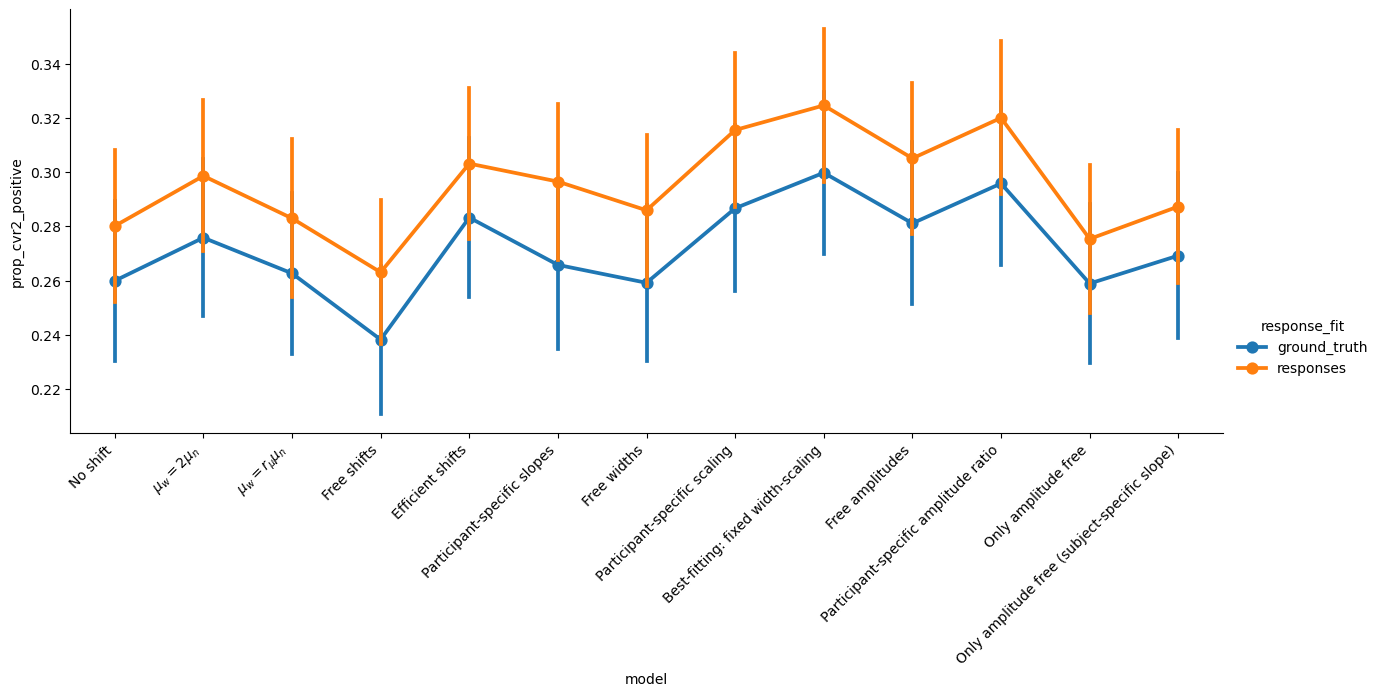

In [21]:
# Plot proportion of voxels with cvr2>0 for each model and subject
proportion_positive_cvr2 = (pars[('cvr2', 'nan')] > 0).groupby(['subject', 'response_fit', 'model']).mean().to_frame('prop_cvr2_positive').reset_index()
import seaborn as sns
sns.catplot(x='model', y='prop_cvr2_positive', data=proportion_positive_cvr2, kind='point', errorbar='se', aspect=2.5, hue='response_fit',
            order=[modelz[m] for m in models])

#rotate x-axis labels
import matplotlib.pyplot as plt
plt.xticks(rotation=45, ha='right')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

order = [modelz[k] for k in sorted(modelz) if modelz[k] in cvr2['model'].unique()]

for response_fit, label in [(False, 'ground truth'), (True, 'responses')]:
    g = sns.catplot(
        data=cvr2[cvr2['response_fit'] == response_fit].groupby(['subject', 'model'])['cvr2'].mean().reset_index(),
        x='model', y='cvr2', kind='point', errorbar='se',
        order=order, aspect=2.0, height=7)
    g.set(title=f'Mean cvr2 — {label}')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
for response_fit, label in [(False, 'ground truth'), (True, 'responses')]:
    g = sns.catplot(
        data=cvr2[cvr2['response_fit'] == response_fit].groupby(['subject', 'model'])['cvr2'].median().reset_index(),
        x='model', y='cvr2', kind='point', errorbar='se',
        order=order, aspect=2.0, height=7)
    g.set(title=f'Median cvr2 — {label}')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()